In [ ]:
#-----User Interface-----
a_ge = 5.43               #in Angstroms
v3 = -1.43                  #form factor for vectors of magnitude sqrt of 3
v8 = 0.27                  #form factor for vectors of magnitude sqrt of 8
v11 = 0.54                 #form factor for vectors of magnitude sqrt of 11
num_vectors = 137         #number of vectors selected
num_points = 100           #number of k-points selected
#------------------------

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

HBAR = 6.582119569e-16  # eV*s
REST_ENERGY_E = 0.51999895069e6  # eV
C = 2.997924580e18  # A/S
M_E = REST_ENERGY_E / (C**2)

def generate_g_vectors(lattice_constant, num_vectors=200):
    """
    Generates reciprocal lattice vectors (G) for an FCC/Diamond lattice.
    """
    # Pre-factor for reciprocal space (2 pi / a[A]) ( x, y ,z )
    prefactor = 2 * np.pi / lattice_constant
    
    # Primitive reciprocal vectors for FCC
    b1 = prefactor * np.array([-1, 1, 1])
    b2 = prefactor * np.array([1, -1, 1])
    b3 = prefactor * np.array([1, 1, -1]) 
    
    # Range of integer indices to search
    # A range of 5 (-5 to 5) is plenty to find the first 200 vectors
    n_range = np.arange(-6, 7)
    
    g_list = []
    
    for h in n_range:
        for k in n_range:
            for l in n_range:
                # G = h*b1 + k*b2 + l*b3
                g = h*b1 + k*b2 + l*b3
                mag = np.linalg.norm(g)
                g_list.append((g, mag))
                
    # Sort vectors by their magnitude (energy cutoff logic)
    g_list.sort(key=lambda x: x[1])
    
    # Extract the top 'num_vectors'
    sorted_g = np.array([item[0] for item in g_list[0:num_vectors]])
    
    return sorted_g

G = generate_g_vectors(a_ge, num_vectors)

print(f"Generated {len(G)} G-vectors.")
#print("First 5 vectors (including origin):\n", G)


# G_i - G_j =  deltaG[i,j]
q = G[:, np.newaxis, :] - G[np.newaxis, :, :]

G_squared_unit = (2 * np.pi / a_ge)**2
q_squared = np.sum(q**2, axis=-1)
q_sq = q_squared / G_squared_unit

tau = a_ge/8 * np.array([1,1,1])
V_matrix = np.zeros_like(q_sq, dtype=float)

S_q = 2*np.cos(np.dot(q, tau))

mask_3 = np.isclose(q_sq, 3.0)
V_matrix[mask_3] = v3 * S_q[mask_3]

mask_8 = np.isclose(q_sq, 8.0)
V_matrix[mask_8] = v8 * S_q[mask_8]

mask_11 = np.isclose(q_sq, 11.0)
V_matrix[mask_11] = v11 * S_q[mask_11]

prefactor = 2 * np.pi / a_ge
L_point = np.array([0.5, 0.5, 0.5]) * prefactor
Gamma_point = np.array([0.0, 0.0, 0.0]) * prefactor
X_point = np.array([1.0, 0.0, 0.0]) * prefactor

k_path_L_G = np.linspace(L_point, Gamma_point, num_points)
# Path 2: Gamma to X (skip the first point to avoid duplicate Gamma)
k_path_G_X = np.linspace(Gamma_point, X_point, num_points)[1:]
k_path = np.vstack((k_path_L_G, k_path_G_X))

distances_L_G = -np.linalg.norm(k_path_L_G - Gamma_point, axis=1) / prefactor
distances_G_X = np.linalg.norm(k_path_G_X - Gamma_point, axis=1) / prefactor
k_dist = np.concatenate((distances_L_G, distances_G_X))


bands = []
for k_vec in k_path:
    # Calculate kinetic energy for this specific k
    # V_matrix is k-independent, so we only update T_matrix
    gpk = G + k_vec[np.newaxis, :]
    g_mags = np.linalg.norm(gpk, axis=1)
    T_matrix = np.diag((HBAR**2 * g_mags**2) / (2 * M_E))
    
    H = T_matrix + V_matrix
    
    # Solve and store the first 8 bands
    eigvals, _ = sp.linalg.eigh(H)
    bands.append(eigvals[0:8])

bands = np.array(bands)
gamma_index = num_points - 1  # Index where k = 0
vbm = bands[gamma_index, 3]   # 4th band at Gamma
shifted_bands = bands - vbm


Generated 137 G-vectors.
E_gamma: 3.4318619408602746 E_low:0.9341989772304924


--- Conduction Band Minimum (Band Index 4) ---
CBM Energy: 0.9185 eV
Found at k-path index: 183
CBM k-vector: [0.98180249 0.         0.        ]
Result: This looks like an indirect band gap.
Lowest point of the first band is at k: [0. 0. 0.]


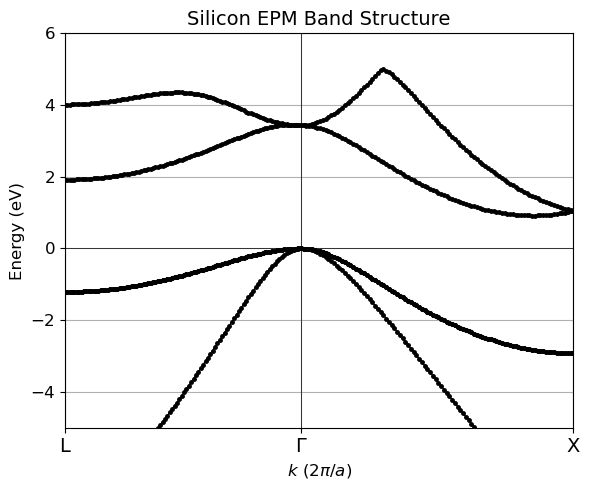

In [13]:
#-------User Interface---------
name = "Silicon"           #name of the crystal for the title
y_min=-5                   #minimum y-value on graph
y_max=6                    #maximum y-value on graph
#------------------------------

cbm_band_idx = 4 

# 1. Extract the specific band column
conduction_band = shifted_bands[:, cbm_band_idx]

# 2. Find the index of the minimum value in that specific band
k_idx_cbm = np.argmin(conduction_band)

# 3. Retrieve the k-vector and the energy value
cbm_k_vector = k_path[k_idx_cbm]
cbm_energy = conduction_band[k_idx_cbm]

print(f"--- Conduction Band Minimum (Band Index {cbm_band_idx}) ---")
print(f"CBM Energy: {cbm_energy:.4f} eV")
print(f"Found at k-path index: {k_idx_cbm}")
print(f"CBM k-vector: {cbm_k_vector}")

# Physics Check: Is it an indirect gap?
gamma_index = num_points - 1
if k_idx_cbm != gamma_index:
    print("Result: This looks like an indirect band gap.")
else:
    print("Result: This looks like a direct band gap at Gamma.")
# Optional: If you only care about the lowest band (index 0)
lowest_band_k_idx = np.argmin(shifted_bands[:, 0])
print(f"Lowest point of the first band is at k: {k_path[lowest_band_k_idx]}")
plt.figure(figsize=(6, 5))
for i in range(6):
    plt.plot(k_dist, shifted_bands[:, i], color='black', marker='.', markersize=5, linewidth=1)
plt.axvline(0, color='black', linewidth=0.5) 
plt.axhline(0, color='black', linewidth=0.5) 

plt.xlim(k_dist[0], k_dist[-1])
plt.ylim(y_min, y_max) 
plt.xticks([k_dist[0], 0, k_dist[-1]], ['L', r'$\Gamma$', 'X'], fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel(r'Energy (eV)', fontsize=12)
plt.xlabel(r'$k \ (2\pi/a)$', fontsize=12)
plt.title('%s EPM Band Structure' %name, fontsize=14)
plt.tight_layout()
plt.grid(True)
plt.show()

In [19]:
import numpy as np
import scipy as sp

k_test_z = np.array([0.0, 0.0, 0.0]) * prefactor
k_test_x = np.array([0.0, 0.0, 0.8]) * prefactor

# 1. Generate a large pool of G-vectors and identify the shells
def get_shell_indices(lattice_constant, max_search=2000):
    prefactor = 2 * np.pi / lattice_constant
    b1, b2, b3 = prefactor*np.array([-1,1,1]), prefactor*np.array([1,-1,1]), prefactor*np.array([1,1,-1])
    
    g_list = []
    n_range = np.arange(-7, 8)
    for h in n_range:
        for k in n_range:
            for l in n_range:
                g = h*b1 + k*b2 + l*b3
                # Use rounding to group vectors into the same shell magnitude
                mag_sq = np.round(np.sum(g**2) / prefactor**2, 4)
                g_list.append((g, mag_sq))
    
    # Sort by magnitude
    g_list.sort(key=lambda x: x[1])
    
    # Find indices where a new shell starts
    mags = [item[1] for item in g_list]
    shell_limits = [i for i in range(1, len(mags)) if mags[i] > mags[i-1]]
    
    return g_list, shell_limits

g_pool, shell_limits = get_shell_indices(a_ge)

# 2. Convergence Loop
results_x = []
results_z = []
n_vectors_list = []

# Test the first 15 shells
for limit in shell_limits[:15]:
    current_G = np.array([item[0] for item in g_pool[:limit]])
    
    # Recalculate V_matrix for this specific size
    q = current_G[:, np.newaxis, :] - current_G[np.newaxis, :, :]
    q_scaled = q / (2 * np.pi / a_ge)
    S_q = np.cos(np.sum(q_scaled * (np.pi / 4), axis=-1))
    q_sq_mag = np.round(np.sum(q_scaled**2, axis=-1), 2)
    
    V = np.zeros_like(q_sq_mag)
    V[np.isclose(q_sq_mag, 3.0)] = v3 * S_q[np.isclose(q_sq_mag, 3.0)]
    V[np.isclose(q_sq_mag, 8.0)] = v8 * S_q[np.isclose(q_sq_mag, 8.0)]
    V[np.isclose(q_sq_mag, 11.0)] = v11 * S_q[np.isclose(q_sq_mag, 11.0)]
    
    # Solve for both directions
    def get_e(k_vec):
        gpk = current_G + k_vec
        T = np.diag((HBAR**2 * np.sum(gpk**2, axis=1)) / (2 * M_E))
        e, _ = sp.linalg.eigh(T + V)
        print(e)
        return e
    results_x.append(get_e(k_test_x))
    results_z.append(get_e(k_test_z))
    n_vectors_list.append(limit)

# results_x and results_z will now be IDENTICAL at every step

[3.20834106]
[0.]
[ 2.54564254  9.95658712  9.95658712 10.47843005 10.953817   25.99829241
 25.99829241 26.55644948 26.74376104]
[-0.50029975 14.76909871 14.76909871 14.76909871 14.76909871 14.76909871
 14.76909871 15.84909871 16.34939846]
[ 2.54564254  6.20742398  9.66603142  9.66603142 10.953817   11.29070482
 22.4705048  22.4705048  22.72047267 23.43048753 26.74376104 26.76582889
 27.07881598 27.07881598 39.66185232]
[-0.50029975 13.57142134 13.57142134 13.57142134 14.76909871 14.76909871
 14.76909871 15.06567587 16.34939846 19.51213161 19.51213161 21.24980898
 21.24980898 21.24980898 21.91555445]
[ 2.53149392  6.18758504  9.41821964  9.41821964 10.82579297 11.21108679
 22.43041595 22.43041595 22.72047267 23.39535941 26.40121003 26.5564879
 26.5564879  26.63462551 26.73089899 27.86144296 27.86144296 28.19791661
 39.63720853 43.32743831 43.39845152 43.39845152 43.60303653 58.81430957
 59.48814706 59.48814706 59.97718158]
[-0.51631398 13.3715785  13.3715785  13.3715785  14.6119937  14

Computed shell with 9 plane waves.
Computed shell with 15 plane waves.
Computed shell with 27 plane waves.
Computed shell with 51 plane waves.
Computed shell with 59 plane waves.
Computed shell with 65 plane waves.
Computed shell with 89 plane waves.
Computed shell with 113 plane waves.
Computed shell with 137 plane waves.
Computed shell with 169 plane waves.
Computed shell with 181 plane waves.
Computed shell with 229 plane waves.
Computed shell with 259 plane waves.
Computed shell with 283 plane waves.


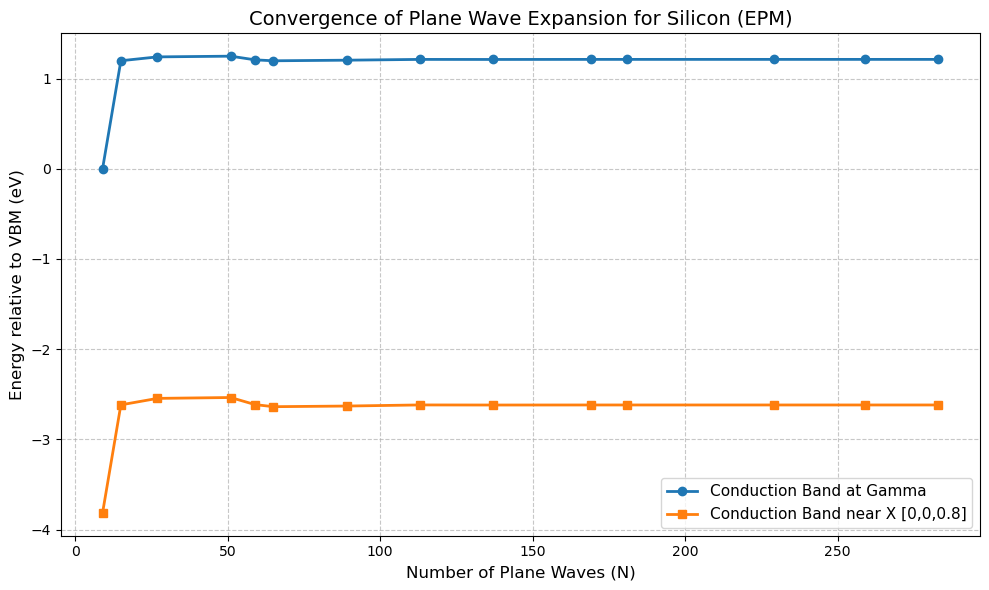

In [24]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

# ----- User Interface -----
a_ge = 5.43               # in Angstroms
v3 = -1.43                # Form factors in eV
v8 = 0.27                 
v11 = 0.54                

# Physical Constants
HBAR = 6.582119569e-16    # eV*s
REST_ENERGY_E = 0.51999895069e6  # eV
C = 2.997924580e18        # A/S
M_E = REST_ENERGY_E / (C**2)
prefactor = 2 * np.pi / a_ge

# The two points you want to compare
Gamma_point = np.array([0.0, 0.0, 0.0]) * prefactor
X_min_point = np.array([0.0, 0.0, 0.8]) * prefactor 

# --- 1. Generate the G-vector Pool and Shell Limits ---
def get_shell_indices(lattice_constant, max_n=5):
    pref = 2 * np.pi / lattice_constant
    b1, b2, b3 = pref*np.array([-1,1,1]), pref*np.array([1,-1,1]), pref*np.array([1,1,-1])
    
    g_list = []
    n_range = np.arange(-max_n, max_n + 1)
    for h in n_range:
        for k in n_range:
            for l in n_range:
                g = h*b1 + k*b2 + l*b3
                mag_sq = np.round(np.sum(g**2) / pref**2, 4)
                g_list.append((g, mag_sq))
                
    g_list.sort(key=lambda x: x[1])
    
    # Identify the indices where a new shell starts
    mags = [item[1] for item in g_list]
    shell_limits = [i for i in range(1, len(mags)) if mags[i] > mags[i-1]]
    
    # Return the pure vectors and the cutoff indices
    return [item[0] for item in g_list], shell_limits

g_pool, shell_limits = get_shell_indices(a_ge)

# --- 2. The Convergence Loop ---
n_vectors_list = []
e_gamma_list = []
e_xmin_list = []

# Loop through the first 15 shells (up to ~250 plane waves)
for limit in shell_limits[:15]:
    current_G = np.array(g_pool[:limit])
    n_vectors = len(current_G)
    
    # --- FIX: Skip basis sets that are too small to have 5 bands ---
    if n_vectors < 5:
        continue
    
    # Recalculate the matrices for this specific basis size
    q = current_G[:, np.newaxis, :] - current_G[np.newaxis, :, :]
    q_scaled = q / prefactor
    q_sq = np.round(np.sum(q_scaled**2, axis=-1), 2)
    
    # Structure factor fixed for proper symmetry
    S_q = np.cos(np.sum(q_scaled * (np.pi / 4), axis=-1))
    
    V_matrix = np.zeros_like(q_sq)
    V_matrix[np.isclose(q_sq, 3.0)] = v3 * S_q[np.isclose(q_sq, 3.0)]
    V_matrix[np.isclose(q_sq, 8.0)] = v8 * S_q[np.isclose(q_sq, 8.0)]
    V_matrix[np.isclose(q_sq, 11.0)] = v11 * S_q[np.isclose(q_sq, 11.0)]
    
    def solve_band(k_vec):
        gpk = current_G + k_vec
        T = np.diag((HBAR**2 * np.sum(gpk**2, axis=1)) / (2 * M_E))
        return sp.linalg.eigvalsh(T + V_matrix)

    # Solve for both k-points
    bands_gamma = solve_band(Gamma_point)
    bands_xmin = solve_band(X_min_point)
    
    # We use the 4th band (index 3) at Gamma as the Valence Band Maximum (VBM) reference
    vbm_ref = bands_gamma[3]
    
    # Store the results for the Conduction Band Minimum (index 4)
    n_vectors_list.append(n_vectors)
    e_gamma_list.append(bands_gamma[4] - vbm_ref)
    e_xmin_list.append(bands_xmin[4] - vbm_ref)
    
    print(f"Computed shell with {n_vectors} plane waves.")

# --- 3. Plotting the Results ---
plt.figure(figsize=(10, 6))

# Plot the energies vs the number of plane waves
plt.plot(n_vectors_list, e_gamma_list, marker='o', linewidth=2, label='Conduction Band at Gamma')
plt.plot(n_vectors_list, e_xmin_list, marker='s', linewidth=2, label='Conduction Band near X [0,0,0.8]')

plt.xlabel("Number of Plane Waves (N)", fontsize=12)
plt.ylabel("Energy relative to VBM (eV)", fontsize=12)
plt.title("Convergence of Plane Wave Expansion for Silicon (EPM)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

# Show the plot
plt.show()

Total shells generated: 100
plane waves: 9 Largest G: [1. 1. 1.]  Energy_gamma: 0.00 Energy_x: -2.41
plane waves: 15 Largest G: [2. 2. 2.]  Energy_gamma: 3.22 Energy_x: 1.04
plane waves: 27 Largest G: [2. 2. 2.]  Energy_gamma: 3.47 Energy_x: 1.09
plane waves: 51 Largest G: [3. 3. 3.]  Energy_gamma: 3.58 Energy_x: 1.20
plane waves: 59 Largest G: [3. 3. 3.]  Energy_gamma: 3.41 Energy_x: 0.94
plane waves: 65 Largest G: [4. 4. 4.]  Energy_gamma: 3.36 Energy_x: 0.85
plane waves: 89 Largest G: [4. 4. 4.]  Energy_gamma: 3.40 Energy_x: 0.89
plane waves: 113 Largest G: [4. 4. 4.]  Energy_gamma: 3.44 Energy_x: 0.94
plane waves: 137 Largest G: [4. 4. 4.]  Energy_gamma: 3.43 Energy_x: 0.93


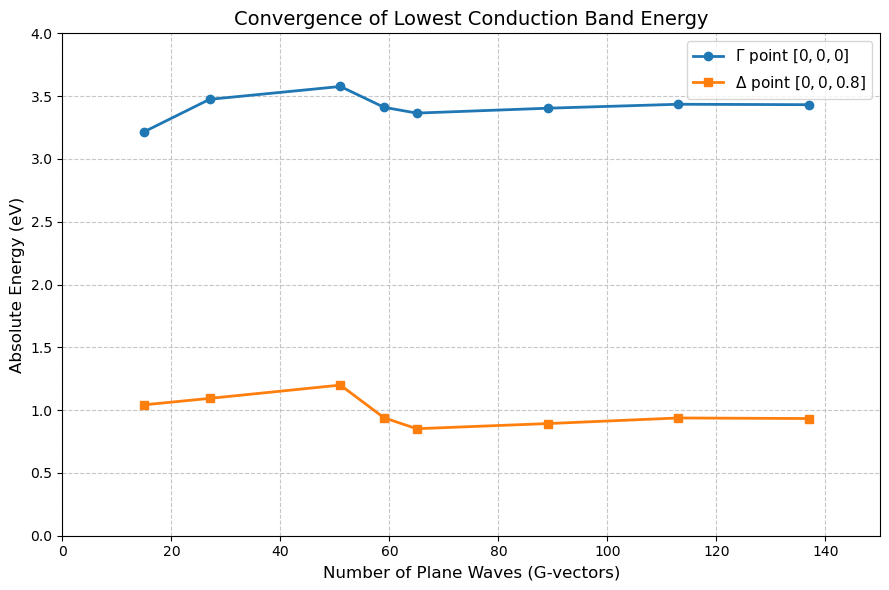

In [42]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

#-----User Interface-----
a_si = 5.43               # Lattice constant in Angstroms (Note: updated variable name from a_ge to a_si)
v3 = -1.43                # form factor for vectors of magnitude squared 3
v8 = 0.27                 # form factor for vectors of magnitude squared 8
v11 = 0.54                # form factor for vectors of magnitude squared 11
max_shells = 10           # Number of reciprocal space shells to include in the convergence test
#------------------------

HBAR = 6.582119569e-16           # eV*s
REST_ENERGY_E = 0.51999895069e6  # eV
C = 2.997924580e18               # A/S
M_E = REST_ENERGY_E / (C**2)
prefactor = 2 * np.pi / a_si

def generate_and_group_g_shells(n_max=6):
    """
    Generates G-vectors and securely groups them into shells of identical magnitudes
    to avoid breaking crystal symmetries.
    """
    b1 = prefactor * np.array([-1, 1, 1])
    b2 = prefactor * np.array([1, -1, 1])
    b3 = prefactor * np.array([1, 1, -1]) 
    
    n_range = np.arange(-n_max, n_max + 1)
    
    g_list = []
    for h in n_range:
        for k in n_range:
            for l in n_range:
                g = h*b1 + k*b2 + l*b3
                g_list.append(g)
                
    g_array = np.array(g_list)
    
    # Calculate magnitudes and round slightly to handle floating point noise
    mags = np.linalg.norm(g_array, axis=1)
    rounded_mags = np.round(mags, 5)

    # Identify unique shell radii
    unique_mags = np.unique(rounded_mags)
    
    shells = []
    for mag in unique_mags:
        mask = np.isclose(rounded_mags, mag)
        shells.append(g_array[mask])
        
    return shells


# 1. Generate shells of G-vectors
g_shells = generate_and_group_g_shells(n_max=6)\

print(f"Total shells generated: {len(g_shells)}")

# 2. Define the exact points in reciprocal space to evaluate
gamma_k = np.array([0.0, 0.0, 0.0]) * prefactor
delta_k = np.array([0.0, 0.0, 0.8]) * prefactor

# Tracking arrays for the convergence plot
num_pw_history = []
gamma_cb_energies = []
delta_cb_energies = []

# Initialize with the 0th shell (just the origin [0,0,0])
current_g = g_shells[0]

# 3. Iteratively add shells and solve the Hamiltonian
# We start the loop at 1 to add the next shell, ensuring we have enough basis 
# vectors to reliably calculate the 5th band (index 4)
for i in range(1, min(max_shells, len(g_shells))):
    current_g = np.vstack((current_g, g_shells[i]))

    num_pw = len(current_g)
    if num_pw <= 4:
        continue
        
    num_pw_history.append(num_pw)
    
    # Build V_matrix for the current basis set
    q = current_g[:, np.newaxis, :] - current_g[np.newaxis, :, :]
    G_squared_unit = prefactor**2
    q_sq = np.sum(q**2, axis=-1) / G_squared_unit
    
    tau = (a_si / 8) * np.array([1, 1, 1])
    V_matrix = np.zeros_like(q_sq, dtype=float)
    
    S_q = 2 * np.cos(np.dot(q, tau))
    
    V_matrix[np.isclose(q_sq, 3.0)] = v3 * S_q[np.isclose(q_sq, 3.0)]
    V_matrix[np.isclose(q_sq, 8.0)] = v8 * S_q[np.isclose(q_sq, 8.0)]
    V_matrix[np.isclose(q_sq, 11.0)] = v11 * S_q[np.isclose(q_sq, 11.0)]
    
    # --- Solve at Gamma Point ---
    gpk_gamma = current_g + gamma_k
    g_mags_gamma = np.linalg.norm(gpk_gamma, axis=1)
    T_gamma = np.diag((HBAR**2 * g_mags_gamma**2) / (2 * M_E))
    H_gamma = T_gamma + V_matrix

    eigvals_gamma, _ = sp.linalg.eigh(H_gamma)
    
    # dynamically find the Valence Band Maximum (Index 3 at Gamma)
    vbm = eigvals_gamma[3]
    
    # Store the lowest Conduction Band (Index 4) RELATIVE to the VBM
    gamma_cb_energies.append(eigvals_gamma[4] - vbm)
    
    # --- Solve at [0, 0, 0.8] Point ---
    gpk_delta = current_g + delta_k
    g_mags_delta = np.linalg.norm(gpk_delta, axis=1)
    T_delta = np.diag((HBAR**2 * g_mags_delta**2) / (2 * M_E))
    H_delta = T_delta + V_matrix
    eigvals_delta, _ = sp.linalg.eigh(H_delta)
    delta_cb_energies.append(eigvals_delta[4] - vbm)
    
    print(f"plane waves: {num_pw} Largest G: {np.max(current_g,0) / prefactor}  Energy_gamma: {(eigvals_gamma[4] - vbm):.2f} Energy_x: {(eigvals_delta[4] - vbm):.2f}")
    # Store the 5th state RELATIVE to the same VBM


# 4. Plotting the Convergence
plt.figure(figsize=(9, 6))

plt.plot(num_pw_history[1:], gamma_cb_energies[1:], marker='o', linewidth=2, label=r'$\Gamma$ point $[0, 0, 0]$')
plt.plot(num_pw_history[1:], delta_cb_energies[1:], marker='s', linewidth=2, label=r'$\Delta$ point $[0, 0, 0.8]$')

plt.title('Convergence of Lowest Conduction Band Energy', fontsize=14)
plt.xlabel('Number of Plane Waves (G-vectors)', fontsize=12)
plt.ylabel('Absolute Energy (eV)', fontsize=12)
plt.ylim(0,4)
plt.xlim(0,150)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()